In [1]:
import pandas as pd


df = pd.read_csv('../data/processed/cleaned_complaints.csv')

df.dropna(inplace=True)

# Define X and y
X = df['narrative']
y = df['product']

print(f"Data loaded ready for ML. Shape: {df.shape}")

Data loaded ready for ML. Shape: (124620, 2)


In [2]:
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split


def clean_text(text):
    text = str(text).lower()
    # The CFPB dataset heavily redacts personal info with 'xxxx'
    text = re.sub(r'x{2,}', ' ', text) 
    # Replace non-alphabet characters with a SPACE to avoid merging words
    text = re.sub(r'[^a-z\s]', ' ', text) 
    # Remove extra multiple spaces and strip leading/trailing spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_narrative'] = df['narrative'].apply(clean_text)
df = df[df['cleaned_narrative'] != '']

X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_narrative'], 
    df['product'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df['product']
)

In [3]:
tfidf = TfidfVectorizer(
    max_features=10000,       # Limits vocabulary to the top 10k most informative terms
    ngram_range=(1, 2),       # Captures unigrams ("credit") and bigrams ("credit report", "late fee")
    min_df=5,                 # Ignores terms that appear in fewer than 5 documents (removes typos)
    max_df=0.8,               # Ignores terms appearing in >80% of documents (corpus-specific stopwords)
    sublinear_tf=True         # Applies sublinear scaling (1 + log(tf)) to dampen the effect of very frequent words
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000, random_state=42)

model_lr.fit(X_train_tfidf,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

Classification Report:
                     precision    recall  f1-score   support

        credit_card       0.81      0.81      0.81      3005
   credit_reporting       0.88      0.90      0.89     11255
    debt_collection       0.82      0.76      0.79      4221
mortgages_and_loans       0.86      0.85      0.86      3751
     retail_banking       0.87      0.88      0.87      2692

           accuracy                           0.86     24924
          macro avg       0.85      0.84      0.84     24924
       weighted avg       0.86      0.86      0.86     24924



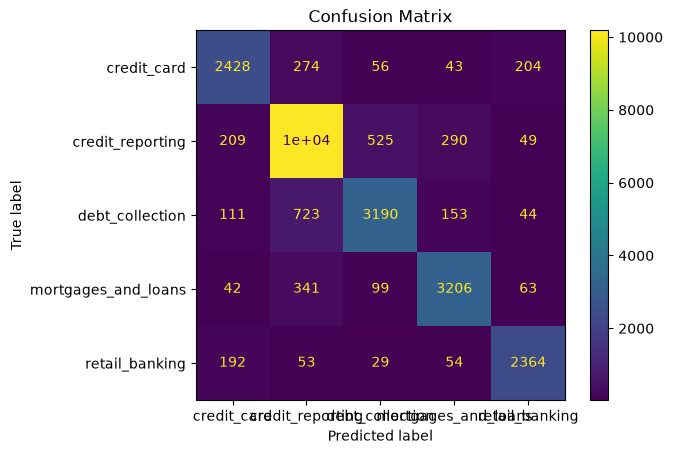

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
)

y_pred = model_lr.predict(X_test_tfidf)

print("Classification Report:")
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix")
plt.show()

--- Logistic Regression (Balanced) ---
                     precision    recall  f1-score   support

        credit_card       0.75      0.85      0.80      3005
   credit_reporting       0.93      0.82      0.87     11255
    debt_collection       0.76      0.82      0.79      4221
mortgages_and_loans       0.80      0.89      0.84      3751
     retail_banking       0.85      0.89      0.87      2692

           accuracy                           0.84     24924
          macro avg       0.82      0.86      0.83     24924
       weighted avg       0.85      0.84      0.84     24924




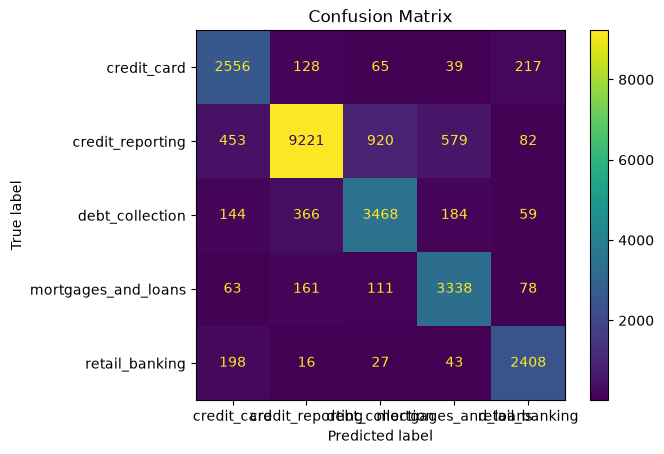

--- LinearSVC (Balanced) ---
                     precision    recall  f1-score   support

        credit_card       0.76      0.82      0.79      3005
   credit_reporting       0.92      0.86      0.89     11255
    debt_collection       0.78      0.80      0.79      4221
mortgages_and_loans       0.83      0.86      0.85      3751
     retail_banking       0.84      0.88      0.86      2692

           accuracy                           0.85     24924
          macro avg       0.82      0.85      0.83     24924
       weighted avg       0.85      0.85      0.85     24924




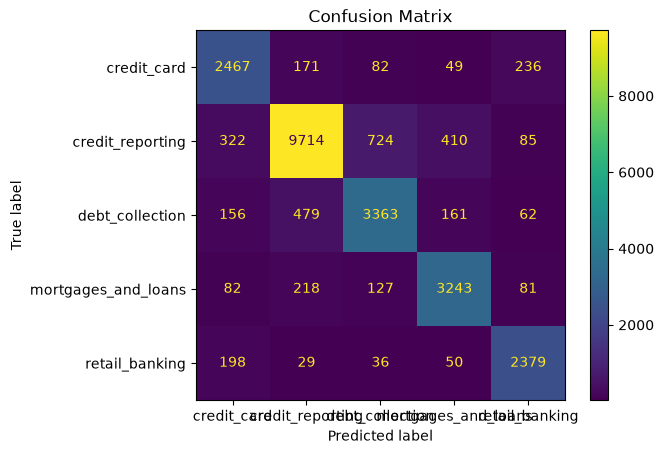

--- Multinomial Naive Bayes ---
                     precision    recall  f1-score   support

        credit_card       0.73      0.78      0.75      3005
   credit_reporting       0.88      0.84      0.86     11255
    debt_collection       0.80      0.69      0.74      4221
mortgages_and_loans       0.75      0.88      0.81      3751
     retail_banking       0.81      0.88      0.85      2692

           accuracy                           0.82     24924
          macro avg       0.79      0.81      0.80     24924
       weighted avg       0.82      0.82      0.82     24924




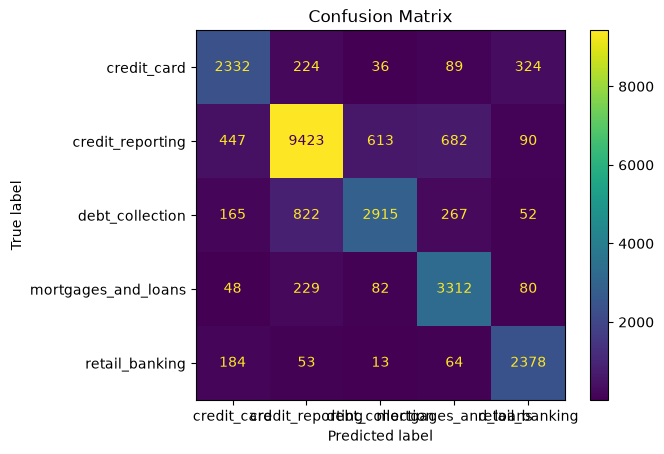

In [6]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

models = {
    "Logistic Regression (Balanced)": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "LinearSVC (Balanced)": LinearSVC(class_weight='balanced', random_state=42, dual=False),
    "Multinomial Naive Bayes": MultinomialNB()
}

for model_name, model in models.items():
    print(f"--- {model_name} ---")
    
    model.fit(X_train_tfidf, y_train)
    
    y_pred = model.predict(X_test_tfidf)
    
    print(classification_report(y_test, y_pred))
    print("="*60 + "\n")

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title("Confusion Matrix")
    plt.show()

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

base_svm = LinearSVC(class_weight='balanced', random_state=42, dual=False)

calibrated_svc = CalibratedClassifierCV(estimator=base_svm, cv=3)

calibrated_svc.fit(X_train_tfidf,y_train)

probs = calibrated_svc.predict_proba(X_test_tfidf[:3])
print(probs)

[[1.12650645e-01 3.86085203e-02 1.12510573e-03 1.77251058e-04
  8.47438478e-01]
 [1.73127588e-02 9.48968033e-01 1.83203848e-02 3.69026671e-03
  1.17085563e-02]
 [1.74177985e-03 5.60679766e-02 1.28652693e-01 8.13518745e-01
  1.88057132e-05]]


In [ ]:
import numpy as np

class_names = calibrated_svc.classes_
print("Class mapping:", class_names)

def get_routing_decision(prob_array, threshold=0.60):

    max_prob = np.max(prob_array)
    best_index = np.argmax(prob_array)

    predicted_class = class_names[best_index]
    
    if max_prob >= threshold:
        return predicted_class, max_prob
    else:
        return "Other Problem", max_prob

test_probs = np.array([1.74177985e-03, 5.60679766e-02, 1.28652693e-01, 8.13518745e-01, 1.88057132e-05])

decision, confidence = get_routing_decision(test_probs, threshold=0.70)
print(f"Routing to: {decision} (Confidence: {confidence *100:.2f})")

Class mapping: ['credit_card' 'credit_reporting' 'debt_collection' 'mortgages_and_loans'
 'retail_banking']
Routing to: mortgages_and_loans (Confidence: 81.35)


In [14]:
import joblib

# Save the trained calibrated model
joblib.dump(calibrated_svc, '../models/calibrated_svc_model.pkl')

# Save the fitted TF-IDF vectorizer
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')

print("Artifacts successfully saved to the models/ directory!")

Artifacts successfully saved to the models/ directory!
